# Using Density Estimation to Find Antigens with Differential Responses

Here we will work with the dataset that contains measurements of antibody responses to a panel of 214 immunoreactive antigens in sera from 87 melioidosis positive and 59 meliotidis negative patients in Singapore. Our goal is to identify immunoreactive antigens that have the most different responses between positive and negative samples (patients). The idea (heuristics) presented in the book

> Yang, Zheng Rong. Machine learning approaches to bioinformatics. Vol. 4. World Scientific, 2010

is the following. 

1. Separate positive and negative samples.
2. Separately for positive and negative samples, normalize the measurements for each antigen.
3. Using PCA, map the normalized data (separately positive and negative) into two dimensions according to the first two principal components.
4. Separately for positive and negative samples, use the transformed 2D data to estimate density using Gaussian kernel density estimation. Two log-density estimations are obtained.
5. Interpret the density as the likelihood of obtaining the (2D) data. Compute PCA differential score for each antigen.
6. Find antigens with the highest differential score as candidates for antigens that can be used to distinguish positive and negative samples.


## Loading the Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import os

In [2]:
BURKHOLDERIA_DATA_URL = 'http://ksvi.mff.cuni.cz/~mraz/bioinf/Materialy/burkholderia' 
BHLD_DATA_PATH = 'Burkholderia_data'

import os
from six.moves import urllib

def fetch_data(source_data_filename,local_data_filename,data_url, local_dir):
    # Store file with the file name source_data_filename at url data_url
    # into the file local_data_filename in a local directory local_dir
    # do that only if the file does not exists in the local_dir.
    if not os.path.isdir(local_dir):
        os.makedirs(local_dir)
    data_path = os.path.join(local_dir, local_data_filename)
    print("datapath",data_path)
    if not os.path.exists(data_path):
        urllib.request.urlretrieve(data_url+'/'+source_data_filename, data_path)
        print('Data have been downloaded')
    else:
        print('No download, data have been found already at a local disk')

In [3]:
fetch_data('burkholderia_pseudomallei','Burkholderia_pseudomallei.csv',BURKHOLDERIA_DATA_URL,BHLD_DATA_PATH)

datapath Burkholderia_data/Burkholderia_pseudomallei.csv
Data have been downloaded


We suppose that data file is in a subdirectory `BHLD_DATA_PATH = 'Burkholderia_data'` and its name is `Burkholderia_pseudomallei.csv`. We read the data and display the first 5 rows of the table. 

In [4]:
data_orig = pd.read_csv(os.path.join(BHLD_DATA_PATH,'Burkholderia_pseudomallei.csv'),header=0,sep='\t')

print('data_orig shape:',data_orig.shape)
data_orig.head()

data_orig shape: (146, 215)


,BPSS1512,BPSL2520,BPSL2522,BPSS1525,BPSS1516,BPSL2096,BPSS1722,BPSS2141,BPSL2698,BPSS0476,...,BPSS1998,BPSS2277,BPSL0606,BPSS0226,BPSS1401,BPSL0361,BPSS0796.2,BPSS1382,BPSS0412,Target
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,333.50,0.0,0.00,...,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0
1,10.33,162.33,132.33,50.33,64.33,0.00,135.33,682.33,0.0,13.33,...,146.33,59.33,0.0,0.0,0.00,0.0,0.0,0.0,60.33,0
2,0.00,0.00,2173.33,0.00,0.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0
3,0.00,534.83,474.83,0.00,0.00,336.83,0.00,673.83,0.0,0.00,...,0.00,0.00,0.0,0.0,126.83,0.0,0.0,0.0,0.00,0
4,5558.33,422.33,156.33,0.00,0.00,0.00,108.33,0.00,0.0,386.33,...,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0


Each row of the table corresponds to one patient (sample). Each of the first 214 columns contains responses to one immunoreactive antigen. The last column indicates whether the patient was melioidosis positive (value `0`) or negative (value `1`). 

Next, we extract negative samples.

In [5]:
noninfected_orig = data_orig[data_orig.Target==1]
print('noninfected_orig shape:',noninfected_orig.shape)
print(noninfected_orig.head())
noninfected_orig.describe()

noninfected_orig shape: (59, 215)
    BPSS1512  BPSL2520  BPSL2522  BPSS1525  BPSS1516  BPSL2096  BPSS1722  \
87       0.0      0.00      0.00       0.0       0.0       0.0       0.0   
88       0.0      0.00      0.00       0.0       0.0       0.0       0.0   
89       0.0      0.00    139.67       0.0       0.0       0.0       0.0   
90     543.0      0.00      0.00       0.0       0.0       0.0       0.0   
91       0.0    568.67      0.00       0.0       0.0       0.0       0.0   

    BPSS2141  BPSL2698  BPSS0476  ...  BPSS1998  BPSS2277  BPSL0606  BPSS0226  \
87       0.0      0.00      0.00  ...       0.0      0.00      0.00       0.0   
88       0.0      0.00     96.33  ...       0.0      0.00      0.00       0.0   
89       0.0      0.00    355.67  ...       0.0      0.00     25.67       0.0   
90       0.0      0.00      0.00  ...       0.0      0.00      0.00    4680.0   
91       0.0    116.67      0.00  ...       0.0   5588.67    509.67       0.0   

    BPSS1401  BPSL0361

,BPSS1512,BPSL2520,BPSL2522,BPSS1525,BPSS1516,BPSL2096,BPSS1722,BPSS2141,BPSL2698,BPSS0476,...,BPSS1998,BPSS2277,BPSL0606,BPSS0226,BPSS1401,BPSL0361,BPSS0796.2,BPSS1382,BPSS0412,Target
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,...,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.0
mean,1992.392881,1201.438136,400.056610,37.632542,913.966271,155.997119,1425.048136,417.890169,726.093051,652.296271,...,97.683729,392.652712,97.073559,598.559322,105.118644,359.090339,402.358814,318.186441,1.810678,1.0
std,5292.340168,1537.205426,709.456577,162.087534,2614.641375,861.466748,2818.626107,1350.736171,2634.472282,2567.937023,...,628.783889,1103.086446,285.678718,2814.418981,757.359249,2012.230246,1288.264151,1893.747694,13.908081,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,298.170000,532.670000,116.330000,0.000000,0.000000,0.000000,395.830000,0.000000,0.000000,47.670000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,1714.420000,1690.750000,500.080000,0.000000,545.415000,0.000000,1102.585000,47.420000,144.085000,283.920000,...,0.000000,26.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,38097.670000,6265.500000,3522.170000,1049.330000,16897.500000,6568.000000,15455.170000,9535.670000,18219.830000,18743.830000,...,4795.500000,5588.670000,1802.330000,18714.500000,5819.500000,14926.830000,7271.500000,14358.500000,106.830000,1.0


In [6]:
# drop the target column
noninfected = noninfected_orig.drop("Target",axis=1)
print("noninfected_orig shape",noninfected_orig.shape)
print("noninfected shape",noninfected.shape)

noninfected_orig shape (59, 215)
noninfected shape (59, 214)


Now, one row corresponds to the data of one noninfected patient.

Next, we extract positive samples.

In [7]:
infected_orig = data_orig[data_orig.Target==0]
print('infected_orig shape:',infected_orig.shape)
print(infected_orig.head())
infected_orig.describe()

infected_orig shape: (87, 215)
   BPSS1512  BPSL2520  BPSL2522  BPSS1525  BPSS1516  BPSL2096  BPSS1722  \
0      0.00      0.00      0.00      0.00      0.00      0.00      0.00   
1     10.33    162.33    132.33     50.33     64.33      0.00    135.33   
2      0.00      0.00   2173.33      0.00      0.00      0.00      0.00   
3      0.00    534.83    474.83      0.00      0.00    336.83      0.00   
4   5558.33    422.33    156.33      0.00      0.00      0.00    108.33   

   BPSS2141  BPSL2698  BPSS0476  ...  BPSS1998  BPSS2277  BPSL0606  BPSS0226  \
0    333.50       0.0      0.00  ...      0.00      0.00       0.0       0.0   
1    682.33       0.0     13.33  ...    146.33     59.33       0.0       0.0   
2      0.00       0.0      0.00  ...      0.00      0.00       0.0       0.0   
3    673.83       0.0      0.00  ...      0.00      0.00       0.0       0.0   
4      0.00       0.0    386.33  ...      0.00      0.00       0.0       0.0   

   BPSS1401  BPSL0361  BPSS0796.2  BP

,BPSS1512,BPSL2520,BPSL2522,BPSS1525,BPSS1516,BPSL2096,BPSS1722,BPSS2141,BPSL2698,BPSS0476,...,BPSS1998,BPSS2277,BPSL0606,BPSS0226,BPSS1401,BPSL0361,BPSS0796.2,BPSS1382,BPSS0412,Target
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,...,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.0
mean,36128.718276,19795.057241,15648.494138,11288.112759,10431.062989,9703.936552,9273.898276,7649.459885,6334.149195,5939.177931,...,230.883218,214.193448,195.107241,165.174253,164.768046,104.492299,77.277701,72.323678,3.429080,0.0
std,25612.979707,22406.200785,19977.507792,19130.438542,16349.811947,12963.334105,13157.282690,12124.231074,11406.860706,10965.615102,...,1045.618769,694.358976,725.402266,1000.539008,526.878659,811.493085,472.819529,502.252571,19.710866,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,4439.165000,754.915000,1117.915000,0.000000,32.165000,0.000000,256.835000,0.000000,0.000000,6.665000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,50733.670000,7349.830000,4293.500000,0.000000,1804.330000,2865.170000,2210.330000,2638.500000,1421.000000,1297.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,59162.085000,37940.920000,25324.085000,13157.165000,12626.165000,16598.000000,14763.330000,8303.835000,5037.665000,6506.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,63639.500000,61150.170000,61007.000000,60151.330000,61211.830000,53783.330000,55374.330000,57352.330000,49895.000000,55197.000000,...,7523.170000,3928.830000,4253.670000,8407.830000,2616.000000,7396.830000,4058.000000,4539.830000,154.170000,0.0


In [8]:
infected = infected_orig.drop("Target",axis=1)
print("infected_orig shape",infected_orig.shape)
print("infected shape",infected.shape)

infected_orig shape (87, 215)
infected shape (87, 214)


## PCA and Visualization of the Data

We are now interested in different immunoreactive antigens, that is, one observation is the list of responses to one antigen. Therefore we transpose our tables.

In [9]:
noninfectedT = noninfected.T
infectedT = infected.T
noninfectedT.head()

,87,88,89,90,91,92,93,94,95,96,...,136,137,138,139,140,141,142,143,144,145
BPSS1512,0.0,0.0,0.00,543.0,0.00,0.0,0.00,118.17,6.5,0.0,...,3313.0,875.83,2837.67,2877.67,0.00,5944.33,347.5,2978.5,8.83,38097.67
BPSL2520,0.0,0.0,0.00,0.0,568.67,0.0,0.00,0.00,337.5,0.0,...,1495.0,1606.83,3926.67,2679.67,1243.17,5807.33,931.5,4600.5,272.83,3241.67
BPSL2522,0.0,0.0,139.67,0.0,0.00,0.0,557.33,1022.17,37.5,0.0,...,1267.0,1069.83,0.00,0.00,229.17,293.33,301.5,0.0,787.83,0.00
BPSS1525,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.00,0.00,0.00,253.5,0.0,0.00,0.00
BPSS1516,0.0,0.0,0.00,0.0,0.00,0.0,574.33,0.00,0.0,0.0,...,0.0,1195.83,0.00,936.67,127.17,9075.33,16897.5,3939.5,0.00,3176.67


For visualization (and further computations) we map the tables using the first two principal components (`n_components=2`) obtained from Principal Component Analysis (PCA)

In [10]:
from sklearn.decomposition import PCA

%matplotlib inline

pca_infected = PCA(n_components=2)
pos2D = pca_infected.fit_transform(infectedT)

pca_noninfected = PCA(n_components=2)
neg2D = pca_noninfected.fit_transform(noninfectedT)

The index of the table `infectedT` is the list of the names of antigens. These are the same for both tables `infectedT` and `noninfectedT`.

In [11]:
desc = list(infectedT.index)
desc[:10]

['BPSS1512',
 'BPSL2520',
 'BPSL2522',
 'BPSS1525',
 'BPSS1516',
 'BPSL2096',
 'BPSS1722',
 'BPSS2141',
 'BPSL2698',
 'BPSS0476']

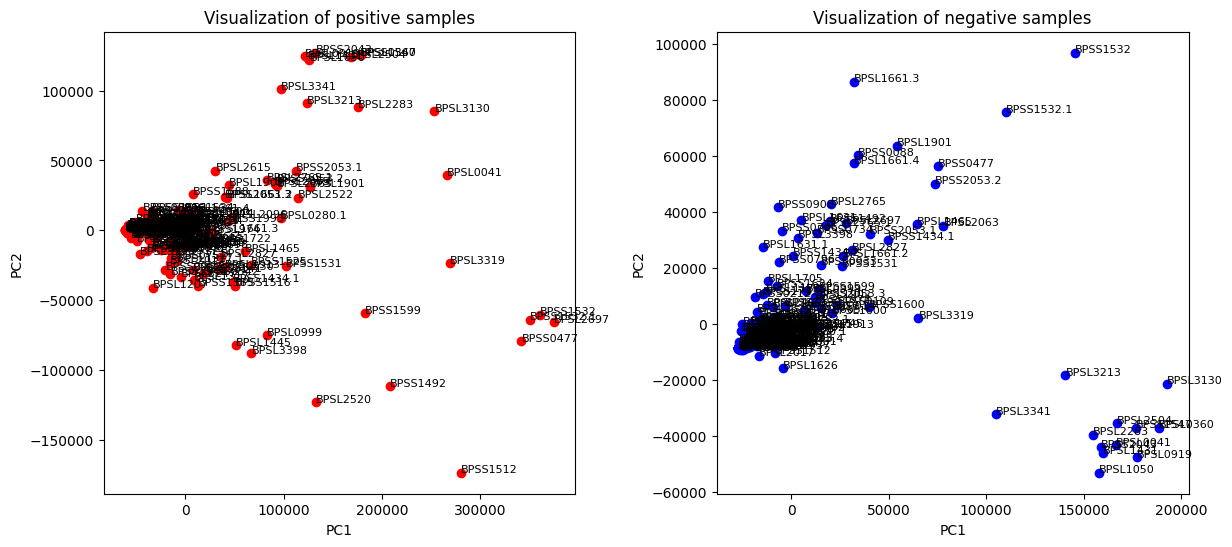

In [12]:
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D

def visualizePCA(fig,subplot,x,y,names,ttl,names_offset=0.1,c='r'):
    ax = fig.add_subplot(subplot,title=ttl,xlabel="PC1",ylabel="PC2")
    for i,d in enumerate(names):
        ax.text(x[i]+names_offset,y[i]+names_offset,d,fontsize=8)
    ax.scatter(x,y,c=c)
    
fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
visualizePCA(fig,121,pos2D[:,0],pos2D[:,1],desc,c="r",ttl="Visualization of positive samples")
visualizePCA(fig,122,neg2D[:,0],neg2D[:,1],desc,c="b",ttl="Visualization of negative samples")

plt.draw()

Note that the corresponding axes in the two subplots have very different ranges. Let us first normalize the data and redo the visualization. This step is not explained in the book 

>    Yang, Zheng Rong. Machine learning approaches to bioinformatics. Vol. 4. World Scientific, 2010

Probably it was done in order to obtain higher values for the density estimators.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

std_scaler_neg = StandardScaler()
std_scaler_neg.fit(noninfectedT)
noninfectedT_std = std_scaler_neg.transform(noninfectedT)
print("noninfectedT_std shape",noninfectedT_std.shape)

In [ ]:
std_scaler_pos = StandardScaler()
std_scaler_pos.fit(infectedT)
infectedT_std = std_scaler_pos.transform(infectedT)
print("infectedT_std shape",infectedT_std.shape)

In [ ]:
pca_infected_std = PCA(n_components=2)
pos2D_std = pca_infected_std.fit_transform(infectedT_std)

pca_noninfected_std = PCA(n_components=2)
neg2D_std = pca_noninfected_std.fit_transform(noninfectedT_std)

In [ ]:
fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
visualizePCA(fig,121,pos2D_std[:,0],pos2D_std[:,1],desc,c="r",ttl="Visualization of positive normalized samples")
visualizePCA(fig,122,neg2D_std[:,0],neg2D_std[:,1],desc,c="b",ttl="Visualization of negative normalized samples")

plt.draw()

The `PCA` object has many attributes. Which of them are the principal components (eigenvectors of the covariance matrix) and where are the corresponding eigenvalues? In the documentation for `PCA`, there are three main attributes: 

* `components_` are the principal components,
* `singular_values_` are the 2-norms of the variables in the lower-dimensional space,
* `explained_variance_` is the amount of variance explained by each of the principal components; it equals the list of n_components largest eigenvalues of the covariance matrix of data, and 
* `explained_variance_ratio_` is the proportion of variance explained by the corresponding principal component.

In [ ]:
print("Eigenvalues:\n",pca_infected_std.singular_values_,"\n","_"*20)
print("Principal components:\n",pca_infected_std.components_,"\n","_"*20)
print("Explained variance:\n",pca_infected_std.explained_variance_,"\n","_"*20)
print("Explained variance ratio:\n",pca_infected_std.explained_variance_ratio_,"\n","_"*20)

In [ ]:
sum(pca_infected_std.explained_variance_ratio_)

Hence, for positive data, almost 57% of the information is presented by the first two principal components and 43% is the information loss when we replace the original data by the projected two-dimensional vectors.

In [ ]:
pca_noninfected_std.explained_variance_ratio_

In [ ]:
sum(pca_noninfected_std.explained_variance_ratio_)

## Verification of Computing PCA

Next, we will compute the principal components and eigenvalues by hand. Just to be sure that the method `.fit_transform()` of the class `PCA` really computes the principal components.

In [ ]:
data = infectedT_std
data

We will compute the covariance matrix. Note that in our case, the attributes are columns of the table. 

In [ ]:
cov_mat=np.cov(data, rowvar=False)     # rowvar = False means that we compute covariance between columns of infectedT
evals, evecs = np.linalg.eig(cov_mat)
print("evals\n", evals)
print("_"*30)
print("evecs\n",evecs.T)               # transposion is used in order to obtain the eigenvectros in rows
print("_"*30)

According to the documentation for `numpy.linalg.eig()`, the returned eigenvalues and eigenvectors need not be sorted. Therefore we sort the eigenvalues and the eigen vectors according to the eigenvalues in an descending order.

In [ ]:
idx = np.argsort(evals)[::-1]
evecs = evecs[:,idx]
evals = evals[idx]
print("evals\n", evals)
print("_"*30)
print("evecs\n",evecs.T)               # transposion is used in order to obtain the eigenvectros in rows
print("_"*30)

Let us verify that we have eigenvectors and eigenvalues. They must satisfy $cov\_mat\cdot evecs_i = evecs_i \cdot evals_i$ for all $i$. That is, `np.dot(cov_mat,evecs) == evecs * evals`. 

In [ ]:
np.allclose(np.dot(cov_mat,evecs), evecs* evals)

Similarly, we can compare the first two principal components and the first two eigenvalues to the results using `PCA.fit_transform()` above.

In [ ]:
print("The first two principal components are correct:",np.allclose(evecs.T[:2,:],pca_infected_std.components_))

**SURPRISE** the first two principal components computed according to slides differ from the principal components computed by `PCA.fit_transform()` above! Actually, the difference is in the sign only. Obviously, if a component computed "manually" points in the opposite direction it preserves the same amount of variance. The first principal component in `evecs` is flipped only.

In [ ]:
print("The first principal component is correct:",np.allclose(-evecs.T[0,:],pca_infected_std.components_[0,:]))
print("The second principal component is correct:",np.allclose(evecs.T[1,:],pca_infected_std.components_[1,:]))


## Gaussian Kernel Density Estimation

Now we will estimate the density normalized antigen measurements for positive and negative data.

In [ ]:
from sklearn.neighbors.kde import KernelDensity

bndw = 1.0/np.sqrt(2)
pos_density = KernelDensity(kernel='gaussian', bandwidth=bndw).fit(pos2D_std)
neg_density = KernelDensity(kernel='gaussian', bandwidth=bndw).fit(neg2D_std)

In [ ]:
def visualizeDensity(fig,subplot,x,y,density,names,ttl,names_offset=0.1,c='r'):
    res = 100
    xx,yy = np.meshgrid(np.linspace(np.min(x),np.max(x),res), np.linspace(np.min(y),np.max(y),res))
    den = density.score_samples(np.column_stack((xx.ravel(),yy.ravel())))
    den.shape = xx.shape

    ax = fig.add_subplot(subplot,title=ttl,xlabel="PC1",ylabel="PC2")
    ax.contourf(np.linspace(np.min(x),np.max(x),res), np.linspace(np.min(y),np.max(y),res),den)
    for i,d in enumerate(names):
        ax.text(x[i]+names_offset,y[i]+names_offset,d,fontsize=8)
    ax.scatter(x,y,c=c)

    
fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
visualizeDensity(fig,121,pos2D_std[:,0],pos2D_std[:,1],pos_density,desc,c="r",ttl="Visualization of positive samples")
visualizeDensity(fig,122,neg2D_std[:,0],neg2D_std[:,1],neg_density,desc,c="b",ttl="Visualization of negative samples")


## PCA Differential Score

In the estimated density for positive and negative data, each antigene has a likelihood of its measurement. Let us denote the likelihood of measurements for the $i$-th antigene in positive data by $p_i^+$ and the likelihood of measurements for the $i$-th antigene in negative data by $p_i^-$. Then, we define normalized likelihood measurements for positive and negative data as
$$\tilde{p}_i^+ = \frac{p_i^+}{\sum_{i} p_i^+} \qquad \text{and} \qquad \tilde{p}_i^- = \frac{p_i^-}{\sum_{i} p_i^-}.$$
Then the *PCA differential score* can be defined as $$\lambda_i = |\tilde{p}_i^+ - \tilde{p}_i^-|.$$

Next, we will identify the top 10 antigens with the highest PCA differential scores.

In [ ]:
pos_sample_logdensity = pos_density.score_samples(pos2D_std)
print("Logdensity of positivesamples\n",pos_sample_logdensity)
print("="*30)
pos_sample_density = np.exp(pos_sample_logdensity)
print("Density of positive samples\n",pos_sample_density)
sum_pos_sample_density = sum(pos_sample_density)
pos_sample_likelihood = pos_sample_density / sum_pos_sample_density
#pos_sample_likelihood = pos_sample_density / np.max(pos_sample_density)
print("Likelihood of positive samples\n",pos_sample_likelihood)

In [ ]:
neg_sample_logdensity = neg_density.score_samples(neg2D_std)
print("Logdensity of negativesamples\n",neg_sample_logdensity)
print("="*30)
neg_sample_density = np.exp(neg_sample_logdensity)
print("Density of negative samples\n",neg_sample_density)
sum_neg_sample_density = sum(neg_sample_density)
neg_sample_likelihood = neg_sample_density / sum_neg_sample_density
#neg_sample_likelihood = neg_sample_density / np.max(neg_sample_density)
print("Likelihood of negative samples\n",neg_sample_likelihood)

In [ ]:
PCA_diff_score = abs(pos_sample_likelihood - neg_sample_likelihood)
print(PCA_diff_score[:10])
idx = np.argsort(PCA_diff_score)[::-1]
print(idx[:10])
PCA_diff_score = PCA_diff_score[idx]
desc_PCA_diff_score = [desc[e] for e in list(idx)]
for d,v in zip(desc_PCA_diff_score[:],PCA_diff_score[:]):
    print(d,v)

Hence, the antigen `BPSL2522` has the maximal PCA differential score (0.9393997973828933). And top 10 differential genes are:

In [ ]:
fig,ax = plt.subplots(figsize=(12,5))
ax.bar(desc_PCA_diff_score[:10],PCA_diff_score[:10])

In [ ]:
def visualizeDensity_and_PCADiffScore(fig,subplot,x,y,density,names,ttl,names_offset=0.1,c='r'):
    res = 100
    xx,yy = np.meshgrid(np.linspace(np.min(x),np.max(x),res), np.linspace(np.min(y),np.max(y),res))
    den = density.score_samples(np.column_stack((xx.ravel(),yy.ravel())))
    den.shape = xx.shape

    ax = fig.add_subplot(subplot,title=ttl,xlabel="PC1",ylabel="PC2")
    ax.contourf(np.linspace(np.min(x),np.max(x),res), np.linspace(np.min(y),np.max(y),res),den)
    for i,d in enumerate(names[:5]):
        ax.text(x[i]+names_offset,y[i]+names_offset,d,fontsize=8)
    ax.scatter(x,y,c=c)

    
fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
visualizeDensity_and_PCADiffScore(fig,121,pos2D_std[idx,0],pos2D_std[idx,1],pos_density,desc_PCA_diff_score,c="r",ttl="Visualization of positive samples")
visualizeDensity_and_PCADiffScore(fig,122,neg2D_std[idx,0],neg2D_std[idx,1],neg_density,desc_PCA_diff_score,c="b",ttl="Visualization of negative samples")


In [ ]:
desc_PCA_diff_score[:5]

In [ ]:
def doubleHist(seriesA,seriesB,bins=40):
    all = np.hstack([seriesA,seriesB])
    mn, mx = (min(all), max(all))
    edges = np.histogram_bin_edges(all,bins=bins)
    fig,ax = plt.subplots()
    ax.hist(seriesA,edges,alpha=0.5)
    ax.hist(seriesB,edges,alpha=0.5)
    

In [ ]:
k=0
doubleHist(infectedT_std[idx[k],:],noninfectedT_std[idx[k],:])

From the double histogram, we can see that the measurements for the antigen `BPSL2522` differ for positive and negative data but the measurements still have a large overlap.

## Compute Differential Score Using Other Dimensionality Reduction Methods

Compute the top 10 differential antigens when we use 
1. multi-dimensional scaling (`sklearn.manifold.MDS`), and
2. locally-linear embedding (`sklearn.manifold.LocallyLinearEmbedding(method='standard',n_neighbors=20)`)

for reducing the data (`infectedT_std` and `noninfectedT_std`) into 2D instead of PCA. Are the top 5 differential antigens the same as for PCA?

In [ ]:
# YOUR CODE GOES HERE

1. Which antigen has the maximal MDS differential score, when we use `sklearn.manifold.MDS` with the additional parameter `random_state=40`?
2. Which antigen has the maximal LLE differential score?
